In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Defining earth
# Earth parameters

R_EARTH = 6_378_137.0       # Earth radius [m](We're using the WGS-84 equatorial radius for now.)
MU_EARTH = 3.986004418e14   # Earth's gravitational parameter [m^3/s^2]

In [3]:
# Satellite altitudes

LEO_ALTITUDE = 600e3       # 600 km
MEO_ALTITUDE = 20_200e3    # 20,200 km

## Calculating orbital radius

In [4]:
LEO_RADIUS = R_EARTH + LEO_ALTITUDE
MEO_RADIUS = R_EARTH + MEO_ALTITUDE

print("LEO orbital radius:", LEO_RADIUS / 1e3, "km")
print("MEO orbital radius:", MEO_RADIUS / 1e3, "km")

LEO orbital radius: 6978.137 km
MEO orbital radius: 26578.137 km


Earth surface

     │
     ├── 600 km ─────────────── LEO
     │
     │
     │
     │
     └── 20,200 km ──────────── MEO/GPS-like

## Calculate orbital angular velocity
## our equation:

$$ n=\sqrt{\frac{\mu}{a^3}} $$



In [5]:
def orbital_angular_velocity(radius):
    return np.sqrt(MU_EARTH / radius**3)

In [6]:
n_leo = orbital_angular_velocity(LEO_RADIUS)
n_meo = orbital_angular_velocity(MEO_RADIUS)

print("LEO angular velocity:", n_leo, "rad/s")
print("MEO angular velocity:", n_meo, "rad/s")

LEO angular velocity: 0.0010830777908964544 rad/s
MEO angular velocity: 0.0001457075595574911 rad/s


## Calculate orbital velocity
	​
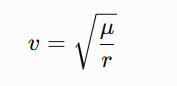
	​


In [7]:
def circular_orbit_velocity(radius):
    return np.sqrt(MU_EARTH / radius)

In [8]:
v_leo = circular_orbit_velocity(LEO_RADIUS)
v_meo = circular_orbit_velocity(MEO_RADIUS)

print("LEO velocity:", v_leo / 1e3, "km/s")
print("MEO velocity:", v_meo / 1e3, "km/s")

LEO velocity: 7.557865206532813 km/s
MEO velocity: 3.872635479854658 km/s


##Actually moving the satellites

For a circular orbit:

$$ \theta(t)=\theta_0+nt $$

We'll choose different starting positions.

In [9]:
LEO_PHASE = 0.0
MEO_PHASE = np.deg2rad(90)

# V1 : Orbital Inclination

In [10]:
LEO_INCLINATION = np.deg2rad(53)
MEO_INCLINATION = np.deg2rad(55)


In [11]:
def rotation_x(inclination):

    return np.array([
        [1, 0, 0],
        [0, np.cos(inclination), -np.sin(inclination)],
        [0, np.sin(inclination),  np.cos(inclination)]
    ])

derive the new coordinates

Start with:

$$ \mathbf r_{PQW} = \begin{bmatrix} r\cos\theta\\ r\sin\theta\\ 0 \end{bmatrix} $$

Multiply by \(R_1(i)\):

$$ \mathbf r_{ECI} = \begin{bmatrix} r\cos\theta\\ r\sin\theta\cos i\\ r\sin\theta\sin i \end{bmatrix} $$

So now:

$$ \boxed{x=r\cos\theta} $$ $$ \boxed{y=r\sin\theta\cos i} $$ $$ \boxed{z=r\sin\theta\sin i} $$

Look at that last equation.

$$ z=r\sin\theta\sin i $$

If:

$$ i=0^\circ $$

then:

$$ z=0 $$

which gives us our V0.

But if:

$$ i=53^\circ $$

then:

$$ z\neq0 $$

and we've got a 3D orbit. 🚀

5. And velocity?

Our V0 velocity was:

$$ \mathbf v_{PQW} = \begin{bmatrix} -rn\sin\theta\\ rn\cos\theta\\ 0 \end{bmatrix} $$

After applying the same rotation:

$$ \boxed{ v_x=-rn\sin\theta } $$ $$ \boxed{ v_y=rn\cos\theta\cos i } $$ $$ \boxed{ v_z=rn\cos\theta\sin i } $$

This is very important later.

Why?

Because Doppler depends on relative velocity along the line of sight.

Eventually we'll need something like:

$$ \boxed{ \dot\rho = \frac{ (\mathbf v_{sat}-\mathbf v_{user}) \cdot (\mathbf r_{sat}-\mathbf r_{user}) }{ \|\mathbf r_{sat}-\mathbf r_{user}\| }} $$

So eventually our satellite's 3D velocity vector matters just as much as its position.

In [12]:
def inclined_circular_orbit_state(
    radius,
    angular_velocity,
    time,
    inclination,
    phase=0.0
):

    theta = phase + angular_velocity * time

    # Position in orbital plane
    position_pqw = np.array([
        radius * np.cos(theta),
        radius * np.sin(theta),
        0.0
    ])

    # Velocity in orbital plane
    velocity_pqw = np.array([
        -radius * angular_velocity * np.sin(theta),
         radius * angular_velocity * np.cos(theta),
         0.0
    ])

    # Rotate orbital plane
    R = rotation_x(inclination)

    position_eci = R @ position_pqw
    velocity_eci = R @ velocity_pqw

    return position_eci, velocity_eci

In [13]:
simulation_time = 24 * 3600
num_steps = 2000

times = np.linspace(
    0,
    simulation_time,
    num_steps
)

leo_positions = []
meo_positions = []

leo_velocities = []
meo_velocities = []


for t in times:

    leo_pos, leo_vel = inclined_circular_orbit_state(
        LEO_RADIUS,
        n_leo,
        t,
        LEO_INCLINATION,
        LEO_PHASE
    )

    meo_pos, meo_vel = inclined_circular_orbit_state(
        MEO_RADIUS,
        n_meo,
        t,
        MEO_INCLINATION,
        MEO_PHASE
    )

    leo_positions.append(leo_pos)
    meo_positions.append(meo_pos)

    leo_velocities.append(leo_vel)
    meo_velocities.append(meo_vel)


leo_positions = np.array(leo_positions)
meo_positions = np.array(meo_positions)

leo_velocities = np.array(leo_velocities)
meo_velocities = np.array(meo_velocities)

In [14]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=leo_positions[:, 0] / 1e3,
            y=leo_positions[:, 1] / 1e3,
            z=leo_positions[:, 2] / 1e3,
            mode='lines',
            name='LEO'
        ),
        go.Scatter3d(
            x=meo_positions[:, 0] / 1e3,
            y=meo_positions[:, 1] / 1e3,
            z=meo_positions[:, 2] / 1e3,
            mode='lines',
            name='MEO'
        )
    ]
)

fig.update_layout(
    title="V1 — Inclined 3D LEO and MEO Orbits",
    scene=dict(
        xaxis_title="X [km]",
        yaxis_title="Y [km]",
        zaxis_title="Z [km]"
    )
)

fig.show()

In [15]:
leo_radii = np.linalg.norm(
    leo_positions,
    axis=1
)

meo_radii = np.linalg.norm(
    meo_positions,
    axis=1
)

print(
    "Maximum LEO radius error:",
    np.max(np.abs(leo_radii - LEO_RADIUS)),
    "m"
)

print(
    "Maximum MEO radius error:",
    np.max(np.abs(meo_radii - MEO_RADIUS)),
    "m"
)

Maximum LEO radius error: 9.313225746154785e-10 m
Maximum MEO radius error: 3.725290298461914e-09 m


In [16]:
leo_speeds = np.linalg.norm(
    leo_velocities,
    axis=1
)

meo_speeds = np.linalg.norm(
    meo_velocities,
    axis=1
)

print(
    "LEO speed:",
    np.min(leo_speeds),
    "to",
    np.max(leo_speeds),
    "m/s"
)

print(
    "MEO speed:",
    np.min(meo_speeds),
    "to",
    np.max(meo_speeds),
    "m/s"
)

LEO speed: 7557.865206532811 to 7557.865206532813 m/s
MEO speed: 3872.635479854657 to 3872.635479854658 m/s
